In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

Q1

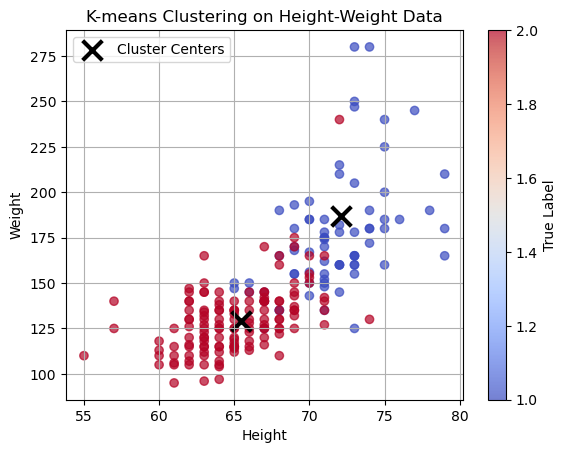

Cluster Centers:
Cluster 1: Height=65.45, Weight=129.26
Cluster 2: Height=72.13, Weight=186.65


In [4]:
data = pd.read_csv("heightWeightData.csv", header=None)

labels = data.iloc[:, 0].values
X = data.iloc[:, 1:3].values

kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(X)

cluster_labels = kmeans.labels_
centers = kmeans.cluster_centers_

idx = np.argsort(labels)
X_sorted = X[idx]
labels_sorted = labels[idx]

plt.Figure(figsize=(8, 6))

scatter = plt.scatter(
    X_sorted[:, 0], 
    X_sorted[:, 1], 
    c=labels_sorted, 
    cmap='coolwarm', 
    alpha=0.7
)

plt.scatter(
    centers[:, 0], 
    centers[:, 1],
    c='black', 
    marker='x', 
    s=200, 
    linewidths=3,
    label='Cluster Centers'
)

plt.xlabel("Height")
plt.ylabel("Weight")
plt.title("K-means Clustering on Height-Weight Data")

plt.legend()

plt.colorbar(scatter, label='True Label')

plt.grid(True)

plt.show()

print("Cluster Centers:")
for i, center in enumerate(centers):
    print(f"Cluster {i+1}: Height={center[0]:.2f}, Weight={center[1]:.2f}")

Q2

In [5]:
def PCA(X, k):
    """
    X: (n_samples, n_features) data matrix
    k: target dimensions
    """

    # 1. Center the data
    X_centered = X - np.mean(X, axis=0)

    # 2. Compute the covariance matrix
    covariance_matrix = np.cov(X_centered, rowvar=False)

    # 3. Eigen decomposition
    eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)

    # 4. Sort eigenvalues and eigenvectors
    sorted_indices = np.argsort(eigenvalues)[::-1]
    sorted_eigenvalues = eigenvalues[sorted_indices]
    sorted_eigenvectors = eigenvectors[:, sorted_indices]

    # 5. Select top k eigenvectors
    W = sorted_eigenvectors[:, :k]

    # 6. Project the data
    X_reduced = X_centered @ W

    return X_reduced, W, sorted_eigenvalues

Q3

In [ ]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1, parser='auto')
X = mnist.data
y = mnist.target.astype(int)

Q4

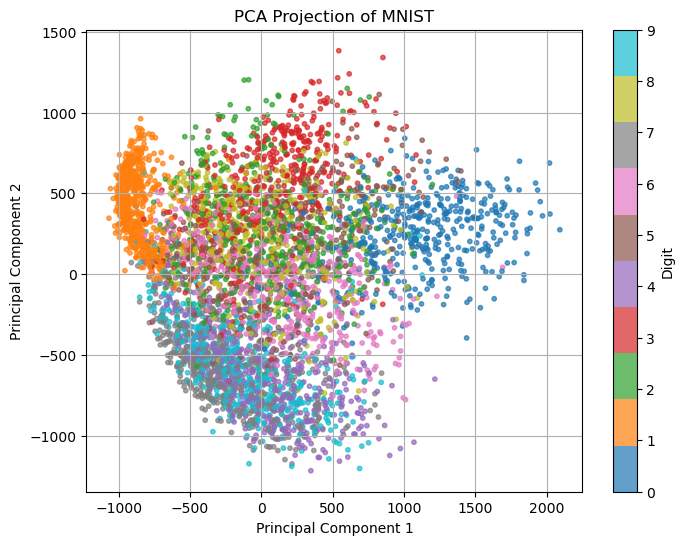

In [12]:
X = X.values
y = y.values

X = X[:5000]
y = y[:5000]

X_reduced, W, eigenvalues = PCA(X, k=2)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_reduced[:, 0],   # PC1
    X_reduced[:, 1],   # PC2
    c=y,               # 用类别上色
    cmap='tab10',      # 10种颜色（对应0-9）
    s=10,
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of MNIST")

# 颜色条（非常加分）
plt.colorbar(scatter, label='Digit')

plt.grid(True)

plt.show()

Q5

In [13]:
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)

# First 2 PCs
variance_2d = explained_variance_ratio[:2].sum()

print("Variance explained by first 2 PCs:", variance_2d)

Variance explained by first 2 PCs: (0.17272112051847974+0j)


Q6

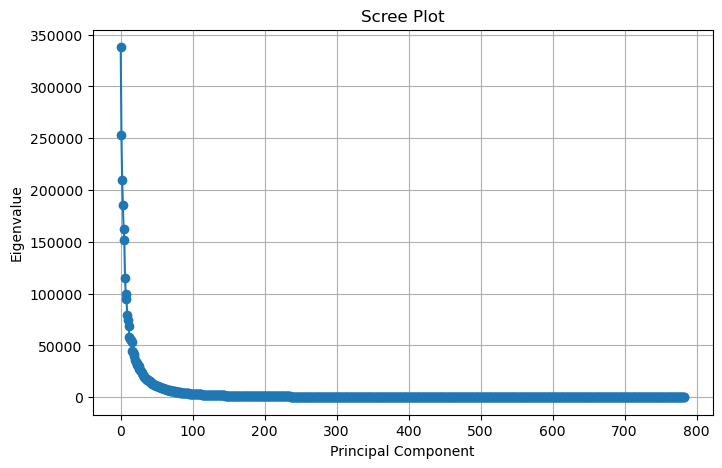

In [14]:
plt.figure(figsize=(8,5))

plt.plot(eigenvalues, marker='o')
plt.title("Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")

plt.grid(True)
plt.show()

Q7

In [15]:
from sklearn.datasets import make_swiss_roll

X, t = make_swiss_roll(n_samples=2000, noise=0.1)

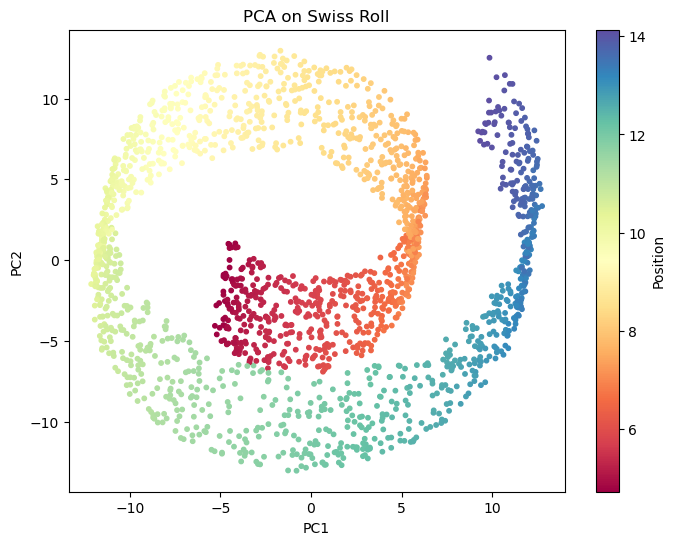

In [16]:
X_reduced, W, eigenvalues = PCA(X, k=2)

plt.figure(figsize=(8,6))

plt.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    c=t,
    cmap='Spectral',
    s=10
)

plt.title("PCA on Swiss Roll")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.colorbar(label='Position')

plt.show()

The PCA projection of the Swiss roll dataset shows that the structure is distorted and overlapping. Although the data originally lies on a nonlinear manifold, PCA fails to unfold it because it is a linear dimensionality reduction method. As a result, points that are distant in the original space may appear close after projection.